# EDA

In [2]:
import pandas as pd

df = pd.read_csv("AP003.csv")
df

,From Date,To Date,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),NH3 (ug/m3),SO2 (ug/m3),CO (mg/m3),...,Temp (degree C),RH (%),WS (m/s),WD (degree),SR (W/mt2),BP (mmHg),VWS (m/s),AT (degree C),RF (mm),Xylene (ug/m3)
0,2017-07-01 00:00:00,2017-07-01 01:00:00,50.00,91.75,3.33,27.70,17.48,NaN,24.35,1.33,...,55.22,83.25,1.67,285.50,6.75,737.0,0.03,26.30,0.00,0.65
1,2017-07-01 01:00:00,2017-07-01 02:00:00,30.75,59.25,1.20,20.78,11.40,0.03,8.23,1.77,...,57.48,84.50,2.50,299.50,6.75,736.0,0.05,25.00,1.50,0.50
2,2017-07-01 02:00:00,2017-07-01 03:00:00,NaN,NaN,1.17,4.07,2.73,0.10,10.77,1.20,...,58.67,86.00,0.77,285.67,6.67,736.0,0.03,24.17,0.33,0.43
3,2017-07-01 03:00:00,2017-07-01 04:00:00,8.00,NaN,2.58,6.38,5.30,NaN,19.78,1.58,...,58.93,86.00,1.55,302.50,6.00,735.0,0.08,24.10,0.00,0.63
4,2017-07-01 04:00:00,2017-07-01 05:00:00,33.25,NaN,5.30,21.03,15.47,0.15,22.40,2.25,...,59.88,86.00,2.30,297.25,6.00,735.0,0.08,24.90,0.00,0.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50395,2023-03-31 19:00:00,2023-03-31 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50396,2023-03-31 20:00:00,2023-03-31 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50397,2023-03-31 21:00:00,2023-03-31 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50398,2023-03-31 22:00:00,2023-03-31 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


I think i saw a whole row being NaN, right?

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50400 entries, 0 to 50399
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   From Date        50400 non-null  object 
 1   To Date          50400 non-null  object 
 2   PM2.5 (ug/m3)    44691 non-null  float64
 3   PM10 (ug/m3)     45018 non-null  float64
 4   NO (ug/m3)       46252 non-null  float64
 5   NO2 (ug/m3)      45705 non-null  float64
 6   NOx (ppb)        47040 non-null  float64
 7   NH3 (ug/m3)      45756 non-null  float64
 8   SO2 (ug/m3)      43604 non-null  float64
 9   CO (mg/m3)       46993 non-null  float64
 10  Ozone (ug/m3)    45309 non-null  float64
 11  Benzene (ug/m3)  46678 non-null  float64
 12  Toluene (ug/m3)  46678 non-null  float64
 13  Temp (degree C)  46335 non-null  float64
 14  RH (%)           46520 non-null  float64
 15  WS (m/s)         46522 non-null  float64
 16  WD (degree)      44710 non-null  float64
 17  SR (W/mt2)  

All data types looks good, but still need to change date columns to datetime.

In [4]:
df["From Date"] = pd.to_datetime(df["From Date"], errors="coerce")
df["To Date"] = pd.to_datetime(df["To Date"], errors="coerce")

Sort by date for sequencing!

In [5]:
df.sort_values("From Date", inplace=True)

Now cleaning up the column names for easier coding.

In [6]:
# Removes any string that starts with a space and continued with braces which has any character inside
df.columns = df.columns.str.replace(r"\s*\(.*?\)", "", regex=True).str.strip()

In [7]:
# Checking nulls
df.isna().sum()

From Date       0
To Date         0
PM2.5        5709
PM10         5382
NO           4148
NO2          4695
NOx          3360
NH3          4644
SO2          6796
CO           3407
Ozone        5091
Benzene      3722
Toluene      3722
Temp         4065
RH           3880
WS           3878
WD           5690
SR           3355
BP           6720
VWS          3357
AT           4030
RF           3252
Xylene       3742
dtype: int64

I think the nulls can be handled with forward and backward fills, because of the time-series nature of the model.

In [8]:
# Check duplicates
df.duplicated().sum()

0

No duplicates! Thats nice to see!
Now continue with splitting data before doing any cleaning to prevent leakage with the training data.

# Cleaning Data

In [9]:
train_split_index = int(len(df) * 0.8)

# Index 0 to 80% of the total data
train_data = df[:train_split_index].reset_index(drop=True)
test_data = df[train_split_index:]

test_split_data = int(len(test_data) * 0.5) # Half of 20% is 10%

# 80% to 90% of the total data
val_data = test_data[:test_split_data].reset_index(drop=True)

# 90% to 100% of the total data
test_data = test_data[test_split_data:].reset_index(drop=True)

Now the code for handling the nulls.

In [10]:
def clean_na(df: pd.DataFrame):
    # Forward fill
    df.ffill(inplace=True)
    
    # Backward fill
    df.bfill(inplace=True)

In [11]:
clean_na(train_data)
clean_na(test_data)
clean_na(val_data)

In [12]:
print(f"Train:\n{train_data.isna().sum()}", end="\n\n")
print(f"Test:\n{test_data.isna().sum()}", end="\n\n")
print(f"Val:\n{val_data.isna().sum()}")

Train:
From Date    0
To Date      0
PM2.5        0
PM10         0
NO           0
NO2          0
NOx          0
NH3          0
SO2          0
CO           0
Ozone        0
Benzene      0
Toluene      0
Temp         0
RH           0
WS           0
WD           0
SR           0
BP           0
VWS          0
AT           0
RF           0
Xylene       0
dtype: int64

Test:
From Date    0
To Date      0
PM2.5        0
PM10         0
NO           0
NO2          0
NOx          0
NH3          0
SO2          0
CO           0
Ozone        0
Benzene      0
Toluene      0
Temp         0
RH           0
WS           0
WD           0
SR           0
BP           0
VWS          0
AT           0
RF           0
Xylene       0
dtype: int64

Val:
From Date    0
To Date      0
PM2.5        0
PM10         0
NO           0
NO2          0
NOx          0
NH3          0
SO2          0
CO           0
Ozone        0
Benzene      0
Toluene      0
Temp         0
RH           0
WS           0
WD           0
SR       

Now that the data are clean, we can continue on preprocessing!

# Preprocessing

Before doing any preprocessing, we need to see the distributions of each numeric columns.

In [13]:
numeric_cols = train_data.select_dtypes("number").columns
numeric_cols

Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'SO2', 'CO', 'Ozone',
       'Benzene', 'Toluene', 'Temp', 'RH', 'WS', 'WD', 'SR', 'BP', 'VWS', 'AT',
       'RF', 'Xylene'],
      dtype='object')

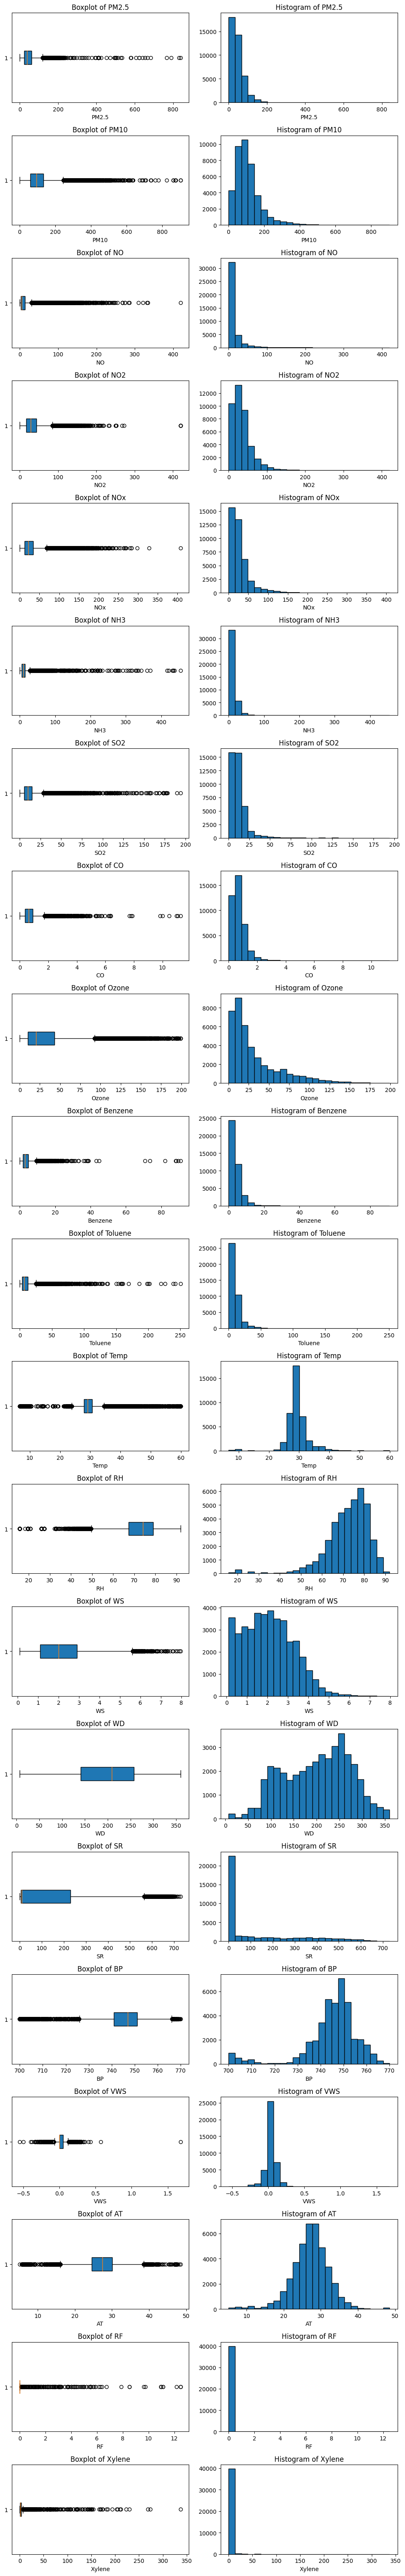

In [14]:
import matplotlib.pyplot as plt

row_count = len(numeric_cols)

fig, axes = plt.subplots(nrows=row_count, ncols=2, figsize=(10, row_count * 3))

for idx, col in enumerate(numeric_cols):
    axes[idx][0].boxplot(train_data[col], vert=False, patch_artist=True)
    axes[idx][0].set_title(f"Boxplot of {col}")
    axes[idx][0].set_xlabel(col)

    axes[idx][1].hist(train_data[col], bins=25, edgecolor="black")
    axes[idx][1].set_title(f"Histogram of {col}")
    axes[idx][1].set_xlabel(col)

fig.tight_layout()
plt.show()

I'll be using RobustScaler and MinMaxScaler for all columns but `RH (Relative Humidity)` and `WD (Wind Direction)`, because the columns has a lot of outliers and neural network models works best when provided with scaled data ranging from 0 to 1. As for `RH (Relative Humidity)` and `WD (Wind Direction)`, I'm just going to use MinMaxScaler because it has an absolute minimum and maximum value of 0-100 and 0-359 respectively.

In [15]:
# Robust-MinMax Scaler class for cleaner code

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from numpy.typing import ArrayLike

class RobustMinMaxScaler:
    def __init__(self):
        self.robust_scaler = RobustScaler()
        self.min_max_scaler = MinMaxScaler()

    def fit_transform(self, X: ArrayLike, y: ArrayLike | None = None ):
        """
        Fit to data, then transform it.

        Fits transformer to `X` and `y` and returns a transformed version of `X`.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Input samples.

        y :  array-like of shape (n_samples,) or (n_samples, n_outputs), \
                default=None
            Target values (None for unsupervised transformations).

        **fit_params : dict
            Additional fit parameters.

        Returns
        -------
        X_new : ndarray array of shape (n_samples, n_features_new)
            Transformed array.
        """
        robust_result = self.robust_scaler.fit_transform(X, y)
        return self.min_max_scaler.fit_transform(robust_result, y)
    
    def transform(self, X: ArrayLike):
        """Center and scale the data.

        Parameters
        ----------
        X : {array-like, sparse matrix} of shape (n_samples, n_features)
            The data used to scale along the specified axis.

        Returns
        -------
        X_tr : {ndarray, sparse matrix} of shape (n_samples, n_features)
            Transformed array.
        """
        robust_result = self.robust_scaler.transform(X)
        return self.min_max_scaler.transform(robust_result)
    
    def inverse_transform(self, X: ArrayLike):
        """Scale back the data to the original representation.

        Parameters
        ----------
        X : {array-like, sparse matrix} of shape (n_samples, n_features)
            The rescaled data to be transformed back.

        Returns
        -------
        X_tr : {ndarray, sparse matrix} of shape (n_samples, n_features)
            Transformed array.
        """
        inversed_minmax = self.min_max_scaler.inverse_transform(X)
        return self.robust_scaler.inverse_transform(inversed_minmax)

In [16]:
scalers = {}

for col in numeric_cols:
    if col in ["RH", "WD"]:
        scalers[col] = MinMaxScaler()
    else:
        scalers[col] = RobustMinMaxScaler()
    
    train_data[col] = scalers[col].fit_transform(train_data[col].to_numpy().reshape(-1,1))
    
train_data

,From Date,To Date,PM2.5,PM10,NO,NO2,NOx,NH3,SO2,CO,...,Temp,RH,WS,WD,SR,BP,VWS,AT,RF,Xylene
0,2017-07-01 00:00:00,2017-07-01 01:00:00,0.059244,0.100498,0.007862,0.065854,0.042817,0.000022,0.125219,0.117908,...,0.912373,0.885246,0.199492,0.788952,0.009247,0.528571,0.260090,0.487535,0.0000,0.001926
1,2017-07-01 01:00:00,2017-07-01 02:00:00,0.036320,0.064507,0.002787,0.049385,0.027924,0.000022,0.042220,0.156915,...,0.954870,0.901639,0.304956,0.828612,0.009247,0.514286,0.269058,0.457525,0.1200,0.001482
2,2017-07-01 02:00:00,2017-07-01 03:00:00,0.036320,0.064507,0.002716,0.009615,0.006687,0.000176,0.055298,0.106383,...,0.977247,0.921311,0.085133,0.789433,0.009137,0.514286,0.260090,0.438366,0.0264,0.001274
3,2017-07-01 03:00:00,2017-07-01 04:00:00,0.009229,0.064507,0.006075,0.015113,0.012982,0.000176,0.101689,0.140071,...,0.982136,0.921311,0.184244,0.837110,0.008219,0.500000,0.282511,0.436750,0.0000,0.001867
4,2017-07-01 04:00:00,2017-07-01 05:00:00,0.039297,0.064507,0.012555,0.049980,0.037893,0.000286,0.115179,0.199468,...,1.000000,0.921311,0.279543,0.822238,0.008219,0.500000,0.282511,0.455217,0.0000,0.001986
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40315,2022-02-04 19:00:00,2022-02-04 20:00:00,0.022030,0.056202,0.020060,0.078706,0.060012,0.028315,0.070745,0.030142,...,0.406732,0.816393,0.285896,0.629603,0.010274,0.671429,0.201794,0.448292,0.0000,0.007705
40316,2022-02-04 20:00:00,2022-02-04 21:00:00,0.018160,0.059524,0.016724,0.073661,0.054501,0.028689,0.071414,0.030142,...,0.432117,0.822951,0.263024,0.622521,0.010959,0.671429,0.210762,0.450600,0.0000,0.005927
40317,2022-02-04 21:00:00,2022-02-04 22:00:00,0.016767,0.074197,0.025348,0.112026,0.082547,0.026051,0.081711,0.074468,...,0.430049,0.829508,0.174079,0.713881,0.010959,0.681000,0.233184,0.451293,0.0000,0.007320
40318,2022-02-04 22:00:00,2022-02-04 23:00:00,0.029473,0.106312,0.026015,0.119214,0.087128,0.023303,0.080167,0.037234,...,0.447537,0.839344,0.110546,0.745042,0.010959,0.685714,0.246637,0.443675,0.0000,0.007557


Transform validation and test data

In [17]:
for col in numeric_cols:
    test_data[col] = scalers[col].transform(test_data[col].to_numpy().reshape(-1,1))

for col in numeric_cols:
    val_data[col] = scalers[col].transform(val_data[col].to_numpy().reshape(-1,1))

# Training

First we need to create some config variables so the code is more readable.

In [20]:
import torch

SEQ_LEN   = 5 # past 5 hours
BATCH     = 64
EPOCHS    = 50
LR        = 1e-3
TARGET    = ["AT"]
FEATURES  = list(numeric_cols)
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"

FEATURES.remove("AT")

And a helper class for our sequence dataset.

In [ ]:
import numpy as np
from torch.utils.data import Dataset
from typing import List

class SequenceDataset(Dataset):
    def __init__(
            self,
            df: pd.DataFrame,
            seq_len: int,
            feature_cols: List[str],
            target_cols: List[str]
        ):
        self.x = []
        self.y = []
        
        # 2D array containing the values of the X and Y columns
        array = df[feature_cols + target_cols].values

        for i in range(len(df) - seq_len):
            # Sliding window for 5 previous input to 1 current output
            self.x.append(array[i:i+seq_len, :len(feature_cols)])
            self.y.append(array[i+seq_len, -len(target_cols):])

        # Convert to fp32 tensor
        self.x = torch.tensor(np.array(self.x), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

Apply the Dataset and Dataloader for pytorch

In [ ]:
from torch.utils.data import DataLoader

train_dataset = SequenceDataset(train_data, SEQ_LEN, FEATURES, TARGET)
val_dataset = SequenceDataset(val_data, SEQ_LEN, FEATURES, TARGET)
test_dataset = SequenceDataset(test_data, SEQ_LEN, FEATURES, TARGET)

# Dataloader can be shuffled, because data already sequenced as:
# X = [
#    [feature1, feature2, ... , feature20], # n-5
#    [feature1, feature2, ... , feature20], # n-4
#    ...
#    [feature1, feature2, ... , feature20], # n-1
# ]
# y = [[target]]
#
train_dataloader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH, shuffle=False)

: 

Creating the model class for cleaner code

In [23]:
from torch import nn

class AirQualityLSTM(nn.Module):
    """
    Air Quality LSTM Model.

    Args
    ----
    n_features : integer
        Number of features the model needs to predict.


    hidden : integer
        Number of neurons in a hidden layer.

    n_layers : integer
        Number of layers in the LSTM model.

    n_out : integer
        Number of target variable.
    
    dropout : float ranging from 0.0 to 1.0
        Percentage of neurons randomly disabled to help training.
    """
    def __init__(
            self,
            n_features: int,
            hidden: int = 64,
            n_layers: int = 1,
            n_out: int = 1,
            dropout: float = 0.0
        ):
        super().__init__()
        
        self.lstm  = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc = nn.Linear(hidden, n_out)

    def forward(self, x):
        out, _ = self.lstm(x)         # (batch, seq_len, hidden)
        return self.fc(out[:, -1])    # use hidden state at last time step

## Baseline Model

Now we create the baseline model with hidden size 10, single layer regressor with linear activation function.

In [ ]:
baseline_model = AirQualityLSTM(
    n_features=len(FEATURES),
    hidden=10,
    n_out=len(TARGET),
    dropout=0.2
).to(DEVICE)

# MSE for criterion
crit = nn.MSELoss()

# Adam optimizer
opt = torch.optim.Adam(baseline_model.parameters(), lr=LR)

Epoch loop for training

In [ ]:
from tqdm.notebook import tqdm
best_val, patience, wait = np.inf, 5, 0

# Progress bar using tqdm
pbar = tqdm(range(EPOCHS), desc="Epoch")

for epoch in pbar:
    # ---- Train ----
    baseline_model.train()
    for xb, yb in train_dataloader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = crit(baseline_model(xb), yb)
        loss.backward()
        opt.step()

    # ---- Validate ----
    baseline_model.eval()
    with torch.no_grad():
        val_losses = [
            crit(baseline_model(xv.to(DEVICE)),
            yv.to(DEVICE)).item() for xv, yv in val_dataloader
        ]

    # Average validation loss 
    val_loss = np.mean(val_losses)

    # Print validation loss to progress bar
    pbar.set_postfix({
        "val_loss": f"{val_loss:.5f}"
    })

    # Early stopping
    if val_loss < best_val:
        best_val, wait = val_loss, 0
        torch.save(baseline_model.state_dict(), "baseline.pt")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

Epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping.


## Modified Model

I will be using optuna to do hyperparameter tuning. First, we create the objective function.

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING) # Suppress normal logging

def create_model(trial: optuna.trial.Trial):
    model = AirQualityLSTM(
        n_features=len(FEATURES),
        hidden=trial.suggest_int("hidden_size", 10, 64, step=2),
        n_layers=trial.suggest_int("n_layers", 1, 8),
        n_out=len(TARGET),
        dropout=0.2
    )

    return model

def objective(trial: optuna.trial.Trial):
    model = create_model(trial)

    # MSE for criterion
    crit = nn.MSELoss()

    # Adam optimizer
    opt = torch.optim.Adam(baseline_model.parameters(), lr=LR)

    # Move to GPU (if available)
    model.to(DEVICE)

    best_val, patience, wait = np.inf, 5, 0

    for _ in range(EPOCHS):
        # ---- Train ----
        model.train()
        for xb, yb in train_dataloader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
    
        # ---- Validate ----
        model.eval()
        with torch.no_grad():
            val_losses = [
                crit(model(xv.to(DEVICE)),
                yv.to(DEVICE)).item() for xv, yv in val_dataloader
            ]
        
        # Average validation loss 
        val_loss = np.mean(val_losses)

        # Early stopping
        if val_loss < best_val:
            best_val, wait = val_loss, 0
            
        else:
            wait += 1
            if wait >= patience: break

    # Average validation loss
    return best_val

Creating a study to find the minimum validation loss.

In [ ]:
# Create optuna study, similar to initializing GridSearchCV
study = optuna.create_study(direction="minimize") # Minimize loss
n_trials = 100

# Progress bar using tqdm
pbar = tqdm(total=n_trials, desc="Optimizing", leave=True)

# Callback to update the progress bar
def tqdm_callback(study: optuna.study.Study, trial: optuna.trial.FrozenTrial):
    pbar.set_postfix(best_val_loss=study.best_value)
    pbar.update(1)

# Similar to GridSearchCV fit()
study.optimize(objective, n_trials=n_trials, callbacks=[tqdm_callback])

print("Best trial:")

trial = study.best_trial

print("  Value: ", trial.value)
print("  Params: ")

# Prints the best hyperparameters
for key, value in trial.params.items():
    print(f"    {key}: {value}")

Optimizing:   0%|          | 0/100 [00:00<?, ?it/s]

e:\CondaEnvs\pyt_cuda\lib\site-packages\torch\nn\modules\rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Best trial:
  Value:  0.002313199308641915
  Params: 
    hidden_size: 34
    n_layers: 7


Now we retrain the model with the best parameter

In [ ]:
best_params = trial.params

model_modified = AirQualityLSTM(
    n_features=len(FEATURES),
    hidden=best_params["hidden_size"],
    n_layers=best_params["n_layers"],
    n_out=len(TARGET),
    dropout=0.2
).to(DEVICE)

# MSE for criterion
crit = nn.MSELoss()

# Adam optimizer
opt = torch.optim.Adam(baseline_model.parameters(), lr=LR)

best_val, patience, wait = np.inf, 5, 0

# Progress bar using tqdm
pbar = tqdm(range(EPOCHS), desc="Epoch")

for epoch in pbar:
    # ---- Train ----
    model_modified.train()
    for xb, yb in train_dataloader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = crit(model_modified(xb), yb)
        loss.backward()
        opt.step()

    # ---- Validate ----
    model_modified.eval()
    with torch.no_grad():
        val_losses = [
            crit(model_modified(xv.to(DEVICE)),
            yv.to(DEVICE)).item() for xv, yv in val_dataloader
        ]

    # Average validation loss 
    val_loss = np.mean(val_losses)

    # Print validation loss to progress bar
    pbar.set_postfix({
        "val_loss": f"{val_loss:.5f}"
    })

    # Early stopping
    if val_loss < best_val:
        best_val, wait = val_loss, 0
        torch.save(model_modified.state_dict(), "modified.pt")
    else:
        wait += 1
        if wait >= patience:
            print("Early stopping.")
            break

Epoch:   0%|          | 0/50 [00:00<?, ?it/s]

Early stopping.


# Testing

Creating helper function for evaluation.

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_model(model: AirQualityLSTM):
    pred_values = []
    y_values = []

    with torch.no_grad():
        for xb, yb in test_dataloader:
            xb = xb.to(DEVICE)
            pred = model(xb)
            
            # Append the inverse transformed values to its corresponding array
            pred_values.append(scalers["AT"].inverse_transform(pred.cpu())[0])
            y_values.append(scalers["AT"].inverse_transform(yb)[0])

    print("Evaluation Result:")
    print(f"    MAE: {mean_absolute_error(y_values, pred_values)}")
    print(f"    MSE: {mean_squared_error(y_values, pred_values)}")
    print(f"    R2: {r2_score(y_values, pred_values)}")

## Baseline Model

I'll be loading the saved model to be evaluated.

In [40]:
baseline_model = AirQualityLSTM(
    n_features=len(FEATURES),
    hidden=10,
    n_out=len(TARGET),
    dropout=0.2
).to(DEVICE)
baseline_model.load_state_dict(torch.load("baseline.pt"))
baseline_model.eval()

eval_model(baseline_model)

Evaluation Result:
    MAE: 16.952400392075127
    MSE: 305.7720154729182
    R2: -15.646508208202757


## Modified Model

Similar to the baseline model, I'll be loading the saved model.

In [ ]:
modified_model = AirQualityLSTM(
    n_features=len(FEATURES),
    hidden=best_params["hidden_size"],
    n_layers=best_params["n_layers"],
    n_out=len(TARGET),
    dropout=0.2
).to(DEVICE)
modified_model.load_state_dict(torch.load("modified.pt"))
modified_model.eval()

eval_model(modified_model)

Evaluation Result:
    MAE: 2.0100042201446584
    MSE: 6.280122091135835
    R2: 0.6581044090090471


# Conclusion

Model A showed poor performance, with a high MAE of 16.95 and a large MSE of 305.77. The R2 score of -15.65 indicates that the model performs drastically worse than a simple mean prediction. This negative R2 value reflects a failure to model the data trend. Model B, on the other hand, demonstrated strong predictive ability, achieving a low MAE of 2.01 and MSE of 6.28. The R2 score of 0.66 indicates that the model explains approximately 66% of the variance in the target variable, suggesting a good fit.

Conclusion: Model B significantly outperforms Model A and is clearly the more suitable choice.